# 06 — Final Evaluation & Model Comparison
**Loan Approval Prediction**

Goals:
- Load all trained models (LR, Decision Tree, Random Forest, Gradient Boosting)
- Compare performance on the held-out test set
- Focus on precision, recall, and F1-score (imbalanced-data metrics)
- Plot confusion matrices for every model
- ROC and Precision-Recall curves (multi-model overlay)
- Select and justify the best model

**Prerequisite**: Notebooks 04 and 05 must have been run.

---

In [24]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # make src/ importable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
)

from src.config import (
    DATA_DIR, MODELS_DIR,
    LR_MODEL_FILE, DT_MODEL_FILE, RF_MODEL_FILE, GB_MODEL_FILE,
)
from src.models import (
    evaluate_model,
    plot_confusion_matrix,
    plot_roc_curves,
    plot_precision_recall,
)

warnings.filterwarnings('ignore')
print("Imports OK — Data dir:", DATA_DIR)

Imports OK — Data dir: /mnt/c/Users/Mega-PC/Desktop/stage Elevvo/Task_4_Loan_Approval_Prediction/data


## 1. Load Data & Models

In [25]:
import numpy as np

X_test = np.load(os.path.join(DATA_DIR, 'X_test.npy'))
y_test = np.load(os.path.join(DATA_DIR, 'y_test.npy'))

with open(os.path.join(DATA_DIR, 'feature_names.pkl'), 'rb') as f:
    feature_names = pickle.load(f)

# Load all trained models
with open(LR_MODEL_FILE, 'rb') as f:
    lr_model = pickle.load(f)

with open(DT_MODEL_FILE, 'rb') as f:
    dt_model = pickle.load(f)

with open(RF_MODEL_FILE, 'rb') as f:
    rf_model = pickle.load(f)

with open(GB_MODEL_FILE, 'rb') as f:
    gb_model = pickle.load(f)

model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting']
models      = [lr_model, dt_model, rf_model, gb_model]

print(f"Test set : {X_test.shape}")
print("Loaded models:", model_names)

Test set : (854, 11)
Loaded models: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting']


## 2. Per-Model Classification Reports

In [26]:
all_metrics = []

for name, model in zip(model_names, models):
    m = evaluate_model(model, X_test, y_test, name)
    all_metrics.append(m)


═══════════════════════════════════════════════════════
  Logistic Regression  —  Evaluation on Test Set
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

Rejected (0)       0.86      0.98      0.92       323
Approved (1)       0.98      0.91      0.94       531

    accuracy                           0.93       854
   macro avg       0.92      0.94      0.93       854
weighted avg       0.94      0.93      0.93       854

  ROC-AUC : 0.9738

═══════════════════════════════════════════════════════
  Decision Tree  —  Evaluation on Test Set
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

Rejected (0)       0.98      0.97      0.97       323
Approved (1)       0.98      0.99      0.98       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854

  ROC-AUC

## 3. Metrics Summary Table

In [27]:
metrics_df = pd.DataFrame(all_metrics)
metrics_df = metrics_df.set_index('model')

cols_to_show = ['accuracy', 'f1_approved', 'f1_rejected', 'f1_macro', 'f1_weighted', 'roc_auc']

display(
    metrics_df[cols_to_show]
    .round(4)
    .style
    .background_gradient(subset=['f1_macro'], cmap='YlGn')
    .format(precision=4)
    .set_caption('Model Comparison — Test Set Metrics')
)

,accuracy,f1_approved,f1_rejected,f1_macro,f1_weighted,roc_auc
model,,,,,,
Logistic Regression,0.9321,0.9431,0.9157,0.9294,0.9328,0.9738
Decision Tree,0.9789,0.9831,0.9720,0.9775,0.9789,0.9764
Random Forest,0.9836,0.9868,0.9783,0.9826,0.9836,0.9988
Gradient Boosting,0.9778,0.9821,0.9705,0.9763,0.9777,0.9983


## 4. Visual Comparison — Key Metrics

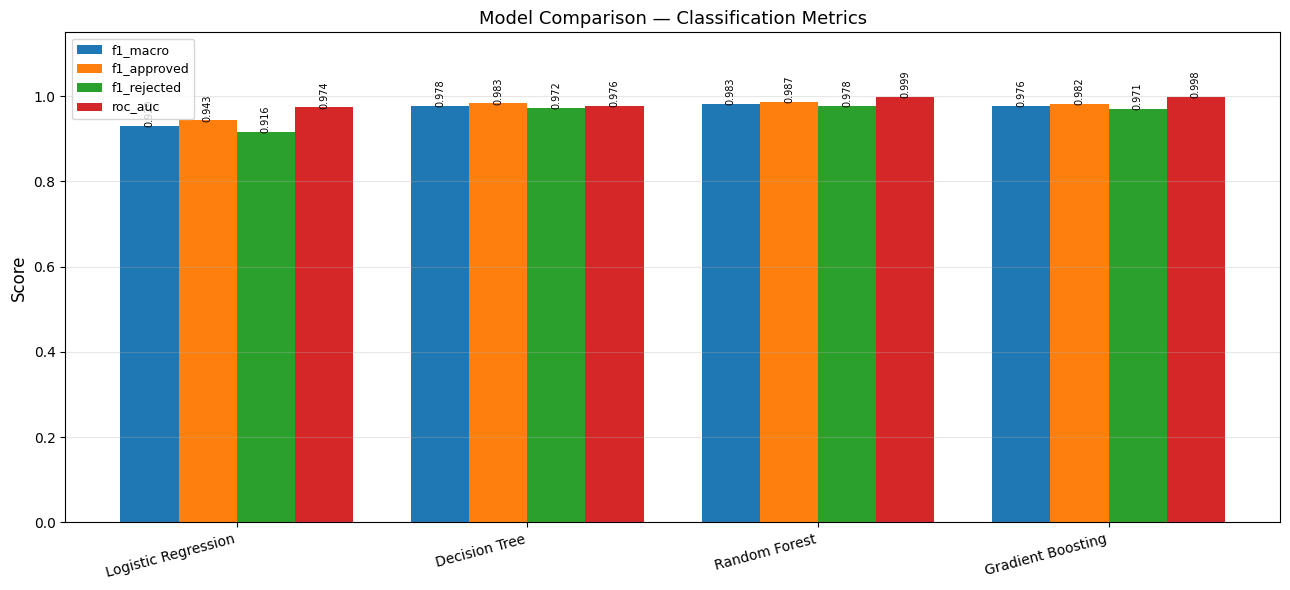

In [28]:
metric_cols = ['f1_macro', 'f1_approved', 'f1_rejected', 'roc_auc']
x     = np.arange(len(model_names))
width = 0.2

fig, ax = plt.subplots(figsize=(13, 6))

for i, metric in enumerate(metric_cols):
    vals = metrics_df[metric].values
    ax.bar(x + i * width, vals, width, label=metric)
    for j, v in enumerate(vals):
        ax.text(
            x[j] + i * width, v + 0.002,
            f'{v:.3f}', ha='center', fontsize=7, rotation=90
        )

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — Classification Metrics', fontsize=13)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Confusion Matrices — All Models

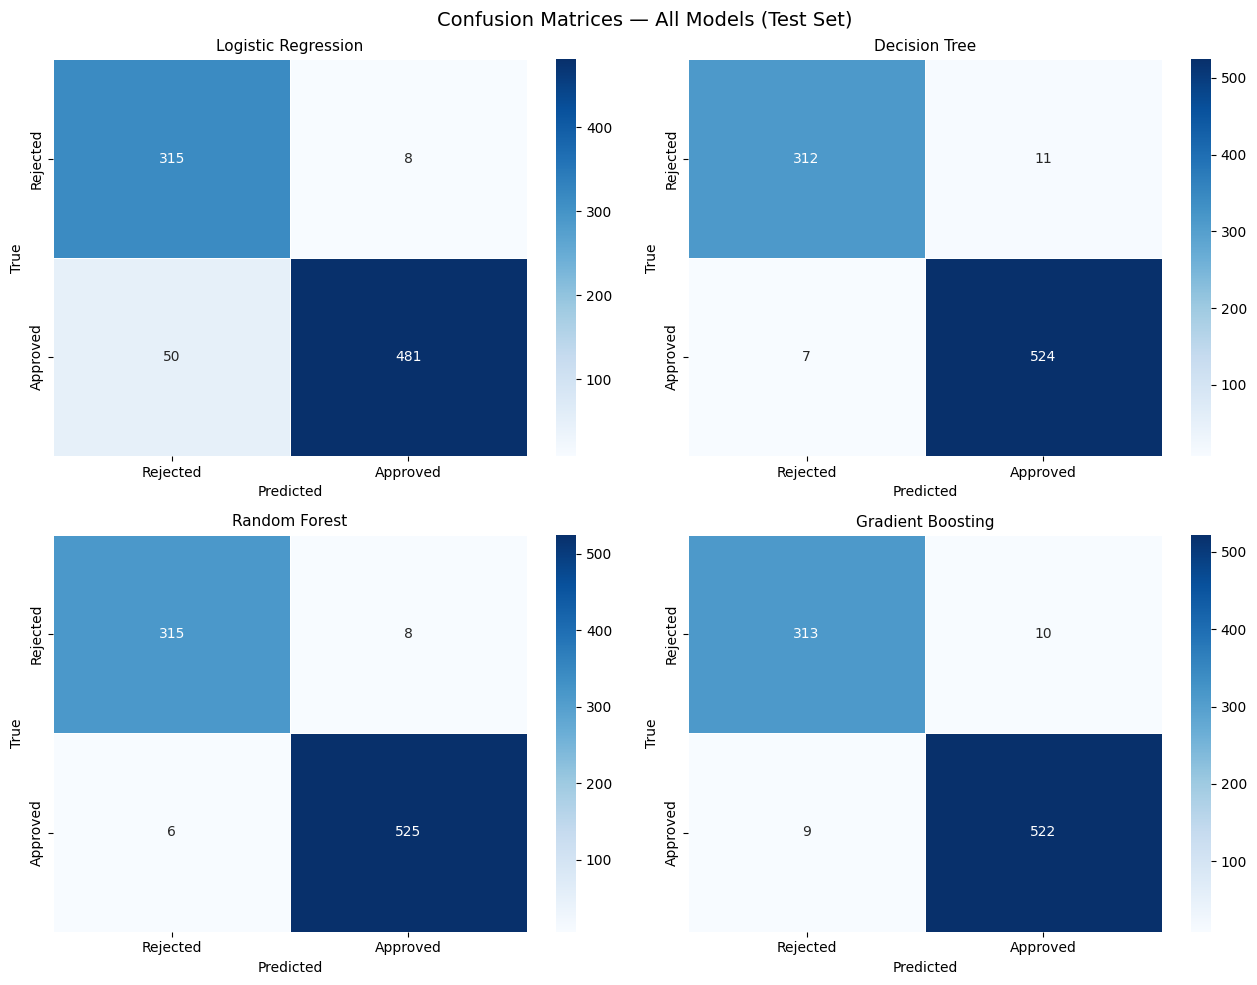

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.ravel()

for i, (name, model) in enumerate(zip(model_names, models)):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[i],
        xticklabels=['Rejected', 'Approved'],
        yticklabels=['Rejected', 'Approved'],
        linewidths=0.5,
    )
    axes[i].set_title(name, fontsize=11)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')

plt.suptitle('Confusion Matrices — All Models (Test Set)', fontsize=14)
plt.tight_layout()
plt.show()

## 6. ROC Curves

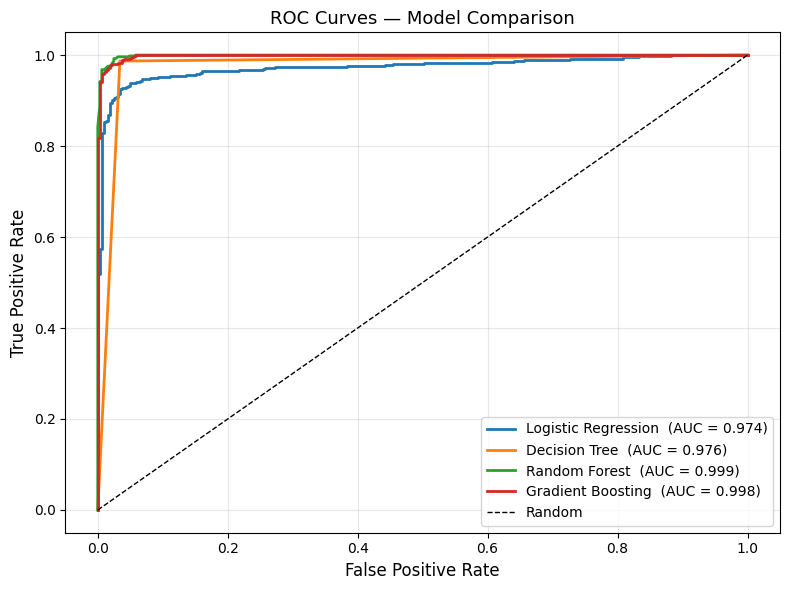

In [30]:
models_dict = dict(zip(model_names, models))
plot_roc_curves(models_dict, X_test, y_test)

## 7. Precision-Recall Curves

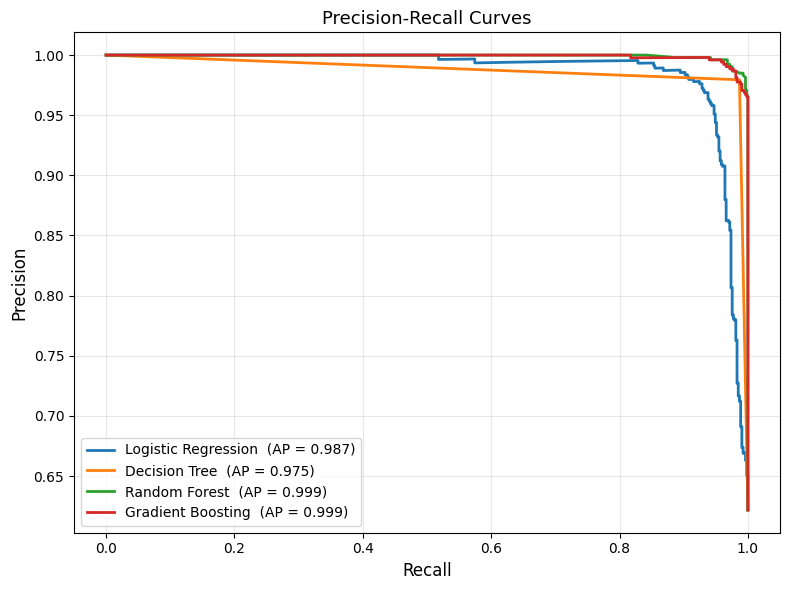

In [31]:
plot_precision_recall(models_dict, X_test, y_test)

## 8. Best Model Selection & Justification

Best model (by Macro-F1): Random Forest
  Macro-F1   : 0.9826
  ROC-AUC    : 0.9988
  F1-Approved: 0.9868
  F1-Rejected: 0.9783


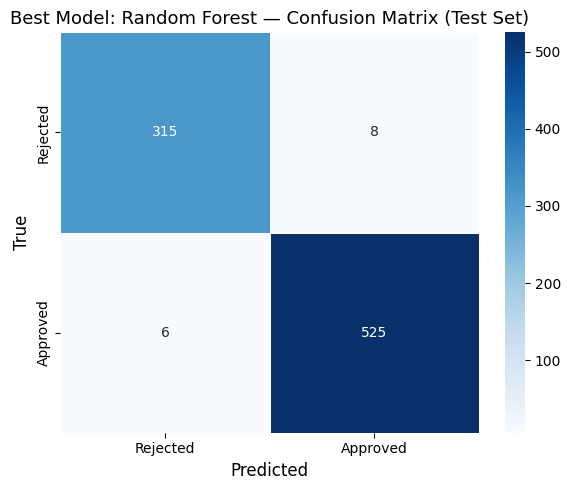

array([[315,   8],
       [  6, 525]])

In [32]:
best_idx   = metrics_df['f1_macro'].values.argmax()
best_name  = metrics_df.index[best_idx]
best_model = models[best_idx]

print(f"Best model (by Macro-F1): {best_name}")
print(f"  Macro-F1   : {metrics_df.loc[best_name, 'f1_macro']:.4f}")
print(f"  ROC-AUC    : {metrics_df.loc[best_name, 'roc_auc']:.4f}")
print(f"  F1-Approved: {metrics_df.loc[best_name, 'f1_approved']:.4f}")
print(f"  F1-Rejected: {metrics_df.loc[best_name, 'f1_rejected']:.4f}")

plot_confusion_matrix(
    y_test,
    best_model.predict(X_test),
    title=f"Best Model: {best_name} — Confusion Matrix (Test Set)"
)

## 9. Threshold Optimisation (for best model)

Optimal threshold for Macro-F1: 0.48
Macro-F1 at threshold 0.48: 0.9850
Macro-F1 at default threshold 0.50: 0.9838
Improvement from threshold tuning: +0.0012


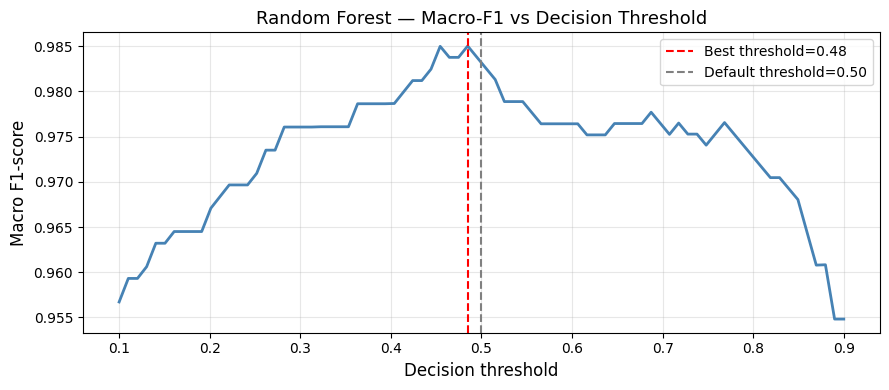

In [33]:
from sklearn.metrics import precision_recall_curve

y_proba_best       = best_model.predict_proba(X_test)[:, 1]
thresholds_pr      = np.linspace(0.1, 0.9, 80)
f1_scores_thresh   = [
    f1_score(y_test, (y_proba_best >= t).astype(int), average='macro', zero_division=0)
    for t in thresholds_pr
]

best_threshold = thresholds_pr[int(np.argmax(f1_scores_thresh))]
print(f"Optimal threshold for Macro-F1: {best_threshold:.2f}")
print(f"Macro-F1 at threshold {best_threshold:.2f}: {max(f1_scores_thresh):.4f}")

# Compare with default threshold
default_f1 = f1_score(
    y_test,
    (y_proba_best >= 0.5).astype(int),
    average='macro',
    zero_division=0,
)
print(f"Macro-F1 at default threshold 0.50: {default_f1:.4f}")
print(f"Improvement from threshold tuning: +{max(f1_scores_thresh) - default_f1:.4f}")

# Plot threshold vs Macro-F1
plt.figure(figsize=(9, 4))
plt.plot(thresholds_pr, f1_scores_thresh, color='steelblue', lw=2)
plt.axvline(
    best_threshold, color='red', linestyle='--',
    label=f'Best threshold={best_threshold:.2f}'
)
plt.axvline(
    0.5, color='gray', linestyle='--',
    label='Default threshold=0.50'
)
plt.xlabel('Decision threshold', fontsize=12)
plt.ylabel('Macro F1-score', fontsize=12)
plt.title(f'{best_name} — Macro-F1 vs Decision Threshold', fontsize=13)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Final Summary

### Model Comparison — Test Set Results

| Model | Accuracy | F1-Macro | F1-Approved | F1-Rejected | ROC-AUC |
|-------|----------|----------|-------------|-------------|---------|
| Logistic Regression | 0.93 | 0.93 | 0.94 | 0.92 | 0.9738 |
| Decision Tree | 0.98 | 0.98 | 0.98 | 0.97 | 0.9764 |
| Random Forest | **0.98** | **0.9826** | **0.9868** | **0.9783** | **0.9988** |
| Gradient Boosting | 0.98 | 0.98 | 0.98 | 0.97 | 0.9983 |

### Best Model: **Random Forest**
- **Macro-F1**: 0.9826
- **ROC-AUC**: 0.9988
- **F1-Approved**: 0.9868 | **F1-Rejected**: 0.9783
- **Confusion Matrix**: 315 TN, 525 TP, 8 FP, 6 FN (only 14 misclassifications out of 854)

### Threshold Optimisation
- Optimal threshold: **0.48** (vs default 0.50)
- Macro-F1 at 0.48: **0.9850** (+0.0012 improvement)

### Key Findings
1. **Tree-based models significantly outperform Logistic Regression** — LR achieves 0.93 accuracy/F1 while all tree models reach 0.98
2. **Random Forest achieves the best overall balance** across all metrics, with the highest ROC-AUC (0.9988) and Macro-F1 (0.9826)
3. **Gradient Boosting is a close second** (ROC-AUC = 0.9983), but Random Forest edges it out on Macro-F1
4. **SMOTE resampling was effective** — Logistic Regression still shows a gap between F1-Approved (0.94) and F1-Rejected (0.92), while tree models achieve near-parity between classes
5. **`cibil_score` is consistently the most important feature** across all tree-based models
6. **Threshold tuning provides marginal improvement** (+0.0012) — the default 0.50 threshold is already near-optimal for Random Forest